<a href="https://colab.research.google.com/github/joanroche444/DeepLearning_assignment/blob/CNN%2Falgorithm/BaselinCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
import cv2
import os
from glob import glob
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


In [2]:
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile

zip_path = '/content/drive/MyDrive/archive (2).zip'  # change this to your actual path
extract_path = '/content/ham10000'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

KeyboardInterrupt: 

In [5]:
df = pd.read_csv('/content/ham10000/HAM10000_metadata.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nClass Distribution:")
print(df['dx'].value_counts())

Dataset Shape: (10015, 7)

First few rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 5

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'nv'),
  Text(1, 0, 'mel'),
  Text(2, 0, 'bkl'),
  Text(3, 0, 'bcc'),
  Text(4, 0, 'akiec'),
  Text(5, 0, 'vasc'),
  Text(6, 0, 'df')])

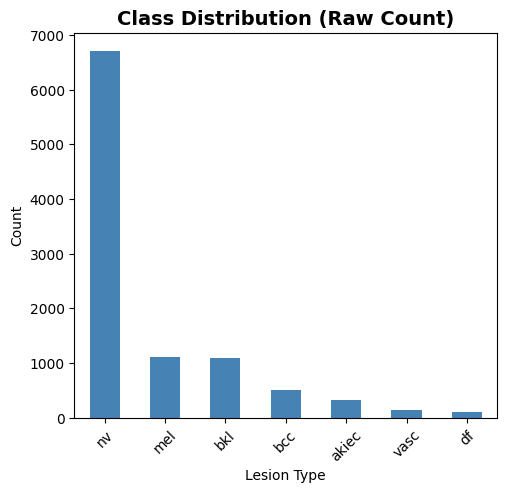

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution (Raw Count)', fontsize=14, fontweight='bold')
plt.xlabel('Lesion Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

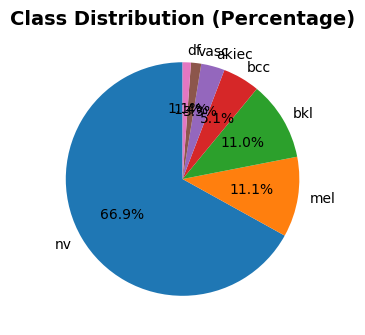


Total images: 10015
Unique lesions: 7470
Duplicate images (same lesion): 2545


In [7]:
plt.subplot(1, 2, 2)
df['dx'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Check for duplicates (same lesion_id)
print(f"\nTotal images: {len(df)}")
print(f"Unique lesions: {df['lesion_id'].nunique()}")
print(f"Duplicate images (same lesion): {len(df) - df['lesion_id'].nunique()}")

In [8]:
# Define image paths
img_dir_1 = '/content/ham10000/HAM10000_images_part_1'
img_dir_2 = '/content/ham10000/HAM10000_images_part_2'


In [9]:
df['path'] = df['image_id'].apply(
    lambda x: os.path.join(img_dir_1, x + '.jpg')
    if os.path.exists(os.path.join(img_dir_1, x + '.jpg'))
    else os.path.join(img_dir_2, x + '.jpg')
)

In [10]:
# Verify all images exist
missing_images = df[~df['path'].apply(os.path.exists)]
print(f"Missing images: {len(missing_images)}")

Missing images: 0


In [11]:
# Label encoding
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

df['cell_type'] = df['dx'].map(lesion_type_dict)
df['cell_type_idx'] = pd.Categorical(df['dx']).codes

print("\nLabel Encoding:")
print(df[['dx', 'cell_type', 'cell_type_idx']].drop_duplicates().sort_values('cell_type_idx'))


Label Encoding:
         dx                      cell_type  cell_type_idx
9687  akiec              Actinic keratoses              0
2462    bcc           Basal cell carcinoma              1
0       bkl  Benign keratosis-like lesions              2
1095     df                 Dermatofibroma              3
1211    mel                       Melanoma              4
64       nv               Melanocytic nevi              5
2320   vasc               Vascular lesions              6


In [12]:
IMG_SIZE = 128
BATCH_SIZE = 32

def load_and_preprocess_image(path, label):
    """Load and preprocess image with augmentation techniques"""
    # Read image
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Remove hair artifacts using morphological operations (common in dermoscopy)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, threshold = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    img = cv2.inpaint(img, threshold, 1, cv2.INPAINT_TELEA)

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize
    img = img / 255.0

    return img, label


Loading sample images...


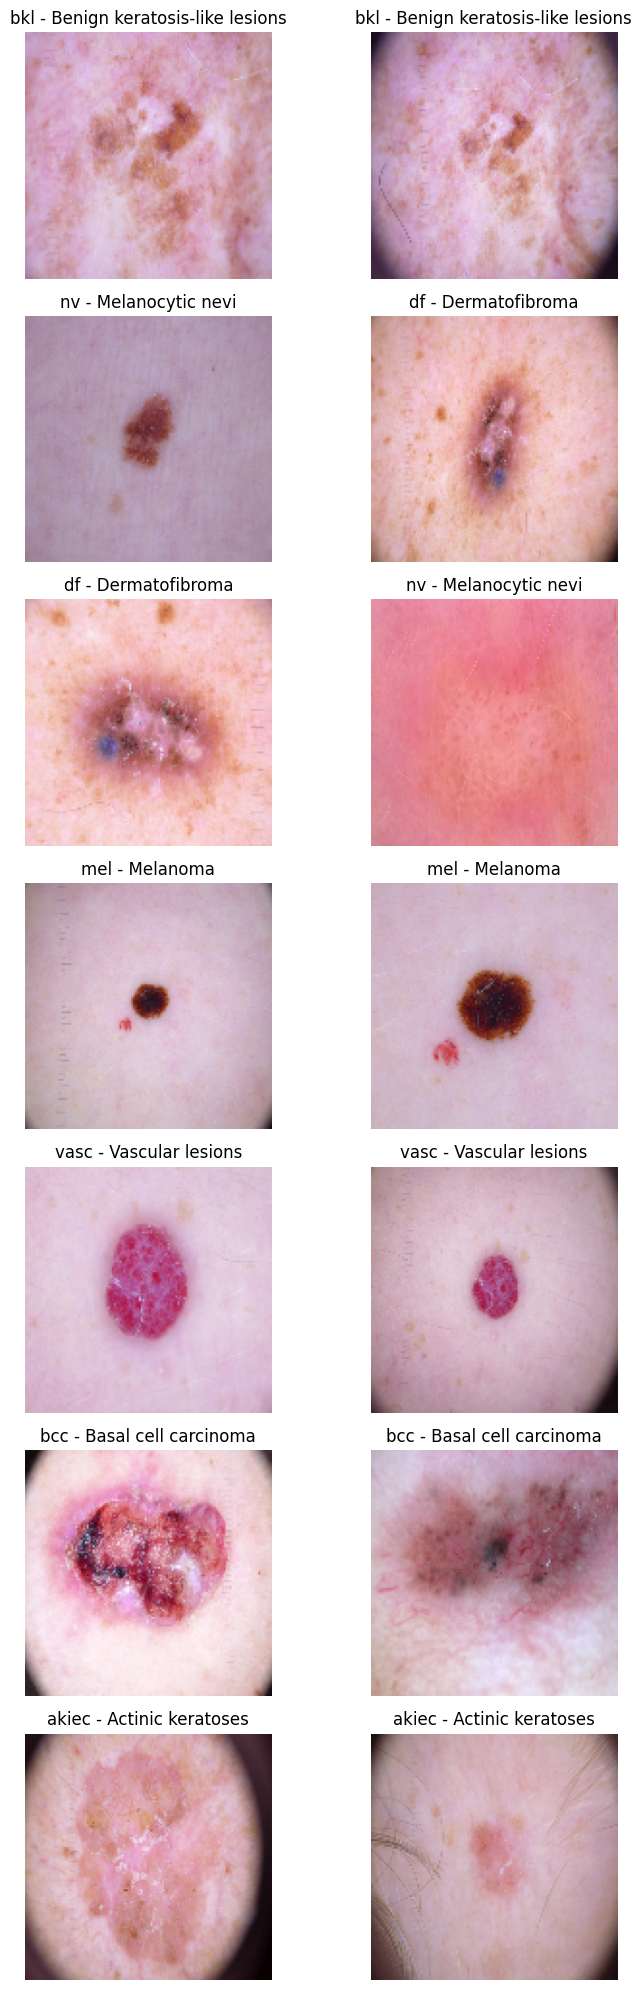

In [13]:
# Load a sample of images for visualization
print("\nLoading sample images...")
sample_df = df.groupby('dx').head(2)
fig, axes = plt.subplots(7, 2, figsize=(8, 20))
for idx, row in enumerate(sample_df.itertuples()):
    img = cv2.imread(row.path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    axes[idx // 2, idx % 2].imshow(img)
    axes[idx // 2, idx % 2].set_title(f"{row.dx} - {row.cell_type}")
    axes[idx // 2, idx % 2].axis('off')
plt.tight_layout()
plt.show()

In [14]:
# Strategy: Augment minority classes to balance the dataset
print("\nBalancing dataset through augmentation...")

# Find target count (median to avoid over-augmentation)
target_count = df['dx'].value_counts().median()
print(f"Target count per class: {int(target_count)}")

augmented_data = []

for lesion_type in df['dx'].unique():
    class_data = df[df['dx'] == lesion_type]
    class_count = len(class_data)

    # Add original data
    augmented_data.append(class_data)

    # Calculate augmentation needed
    if class_count < target_count:
        aug_needed = int(target_count - class_count)
        # Sample with replacement and augment
        sampled = class_data.sample(n=aug_needed, replace=True, random_state=42)
        augmented_data.append(sampled)

# Combine all data
df_balanced = pd.concat(augmented_data, ignore_index=True)
print(f"\nBalanced dataset size: {len(df_balanced)}")
print("\nBalanced class distribution:")
print(df_balanced['dx'].value_counts())



Balancing dataset through augmentation...
Target count per class: 514

Balanced dataset size: 10973

Balanced class distribution:
dx
nv       6705
mel      1113
bkl      1099
df        514
vasc      514
bcc       514
akiec     514
Name: count, dtype: int64


In [15]:

# Stratified split to maintain class distribution
X = df_balanced['path'].values
y = df_balanced['cell_type_idx'].values

# First split: train and temp (80-20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: validation and test (50-50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")



Train set: 8778 images
Validation set: 1097 images
Test set: 1098 images


In [16]:
# Training data augmentation (aggressive for medical images)
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

# Validation and test (only rescaling)
val_test_datagen = ImageDataGenerator()

# Load images
print("\nLoading and preprocessing images...")


Loading and preprocessing images...


In [17]:
X_train_imgs = np.array([load_and_preprocess_image(path, label)[0]
                         for path, label in tqdm(zip(X_train, y_train), total=len(X_train))])
X_val_imgs = np.array([load_and_preprocess_image(path, label)[0]
                       for path, label in tqdm(zip(X_val, y_val), total=len(X_val))])
X_test_imgs = np.array([load_and_preprocess_image(path, label)[0]
                        for path, label in tqdm(zip(X_test, y_test), total=len(X_test))])

y_train_cat = keras.utils.to_categorical(y_train, num_classes=7)
y_val_cat = keras.utils.to_categorical(y_val, num_classes=7)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=7)

print(f"Training data shape: {X_train_imgs.shape}")
print(f"Validation data shape: {X_val_imgs.shape}")
print(f"Test data shape: {X_test_imgs.shape}")

100%|██████████| 1098/1098 [00:46<00:00, 23.71it/s]


Training data shape: (8778, 128, 128, 3)
Validation data shape: (1097, 128, 128, 3)
Test data shape: (1098, 128, 128, 3)


In [18]:
"""
MODEL ARCHITECTURE JUSTIFICATION:
---------------------------------
1. Multiple Conv-BatchNorm-Activation blocks: Extract hierarchical features
2. Batch Normalization: Stabilize training and allow higher learning rates
3. Dropout: Prevent overfitting (critical for medical images)
4. Global Average Pooling: Reduce parameters and overfitting vs Flatten
5. Dense layers with L2 regularization: Final classification with regularization
6. He initialization: Better for ReLU activations

Activation Functions:
- ReLU: Faster training, avoids vanishing gradients
- Softmax: Multi-class probability distribution

Loss Function: Categorical Crossentropy for multi-class classification
Optimizer: Adam with learning rate scheduling
"""

def create_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=7):
    """
    Custom CNN architecture optimized for skin lesion classification
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # Block 1: Initial feature extraction
        layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2: Deeper features
        layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3: High-level features
        layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 4: Complex patterns
        layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Global pooling and classification
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create model
model = create_custom_cnn()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,443,879 (5.51 MB)

 Trainable params: 1,440,423 (5.49 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [19]:
# Calculate class weights for original imbalanced data
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(df['cell_type_idx']),
    y=df['cell_type_idx']
)
class_weights_dict = dict(enumerate(class_weights))
print("\nClass weights:", class_weights_dict)

def scheduler(epoch, lr):
    if epoch < 10:
        return float(lr)
    else:
        return float(lr * tf.math.exp(-0.1))


# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.LearningRateScheduler(scheduler, verbose=0)
]

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)


Class weights: {0: np.float64(4.375273044997815), 1: np.float64(2.78349082823791), 2: np.float64(1.301832835044846), 3: np.float64(12.440993788819876), 4: np.float64(1.2854575792581184), 5: np.float64(0.21338020666879728), 6: np.float64(10.075452716297788)}


In [20]:
print("\n" + "="*70)
print("TRAINING CUSTOM CNN MODEL")
print("="*70)

EPOCHS = 50

history = model.fit(
    train_datagen.flow(X_train_imgs, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_val_imgs, y_val_cat),
    epochs=EPOCHS,
    callbacks=callbacks_list,
    class_weight=class_weights_dict,
    verbose=1
)


TRAINING CUSTOM CNN MODEL
Epoch 1/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.1160 - auc: 0.4672 - loss: 5.4199 - precision: 0.1106 - recall: 0.0497
Epoch 1: val_accuracy improved from -inf to 0.10027, saving model to best_model.keras
275/275 ━━━━━━━━━━━━━━━━━━━━ 101s 274ms/step - accuracy: 0.1159 - auc: 0.4671 - loss: 5.4196 - precision: 0.1105 - recall: 0.0497 - val_accuracy: 0.1003 - val_auc: 0.4530 - val_loss: 12.6557 - val_precision: 0.1003 - val_recall: 0.1003 - learning_rate: 0.0010
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.0711 - auc: 0.4231 - loss: 4.7218 - precision: 0.0607 - recall: 0.0223
Epoch 2: val_accuracy did not improve from 0.10027
275/275 ━━━━━━━━━━━━━━━━━━━━ 51s 185ms/step - accuracy: 0.0710 - auc: 0.4230 - loss: 4.7213 - precision: 0.0606 - recall: 0.0223 - val_accuracy: 0.0474 - val_auc: 0.5546 - val_loss: 8.6186 - val_precision: 0.0474 - val_recall: 0.0474 - learning_rate: 0.0010
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 

In [22]:

model = keras.models.load_model('best_model.keras')

# Evaluate on test set
print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)

test_loss, test_acc, test_auc, test_precision, test_recall = model.evaluate(
    X_test_imgs, y_test_cat, verbose=0
)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")

# Predictions
y_pred_proba = model.predict(X_test_imgs, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
target_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
print(classification_report(y_test, y_pred, target_names=target_names))


TEST SET EVALUATION

Test Accuracy: 10.02%
Test Loss: 12.6754
Test AUC: 0.4520
Test Precision: 0.1002
Test Recall: 0.1002
Test F1-Score: 0.1002

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        52
         bcc       0.00      0.00      0.00        51
         bkl       0.10      1.00      0.18       110
          df       0.00      0.00      0.00        52
         mel       0.00      0.00      0.00       111
          nv       0.00      0.00      0.00       671
        vasc       0.00      0.00      0.00        51

    accuracy                           0.10      1098
   macro avg       0.01      0.14      0.03      1098
weighted avg       0.01      0.10      0.02      1098



KeyError: 'lr'

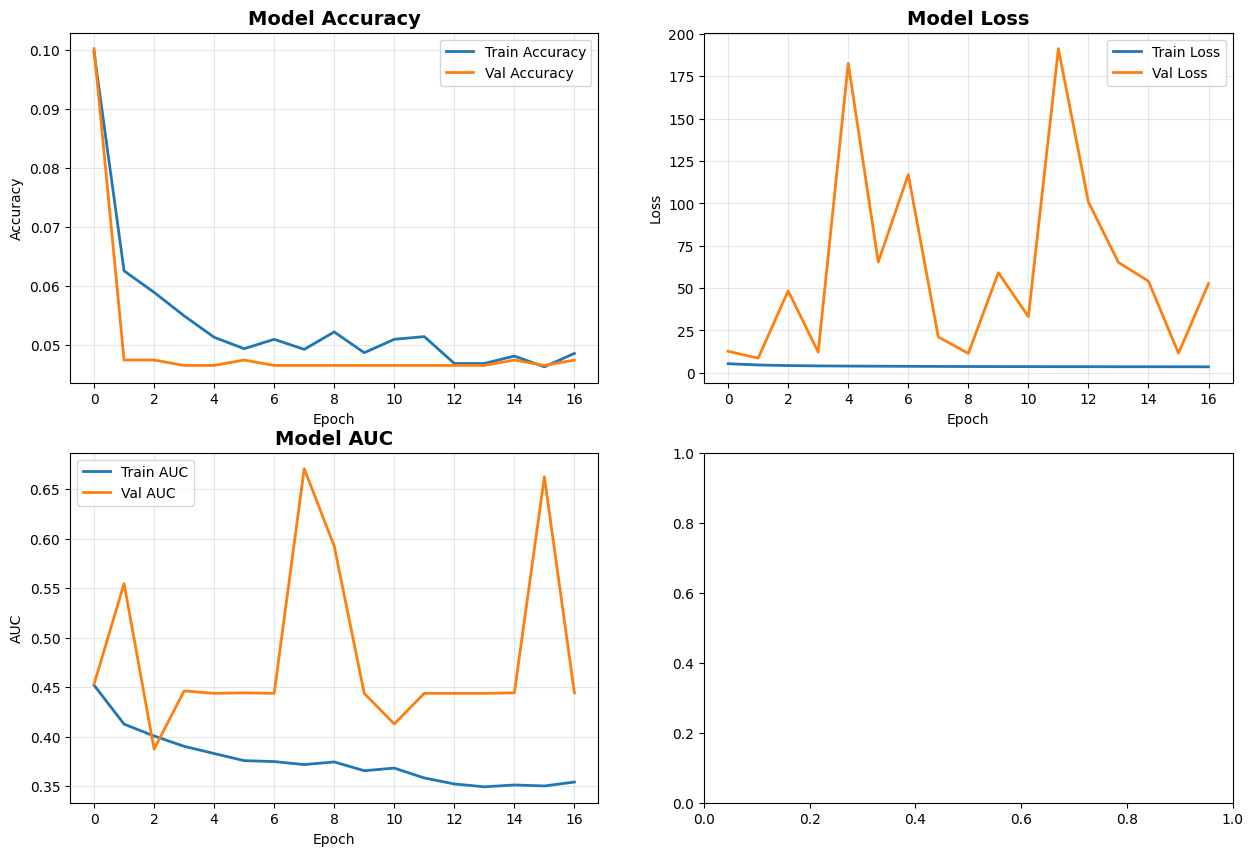

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[1, 0].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(history.history['lr'], linewidth=2, color='green')
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [24]:
##baseline model
  # Change to '/kaggle/input/skin-cancer-mnist-ham10000/' if on Kaggle

df = pd.read_csv('/content/ham10000/HAM10000_metadata.csv')
print(f"\nTotal images: {len(df)}")
print("\nOriginal class distribution:")
print(df['dx'].value_counts())

# Image paths
img_dir_1 = '/content/ham10000/HAM10000_images_part_1'
img_dir_2 = '/content/ham10000/HAM10000_images_part_2'

df['path'] = df['image_id'].apply(
    lambda x: os.path.join(img_dir_1, x + '.jpg')
    if os.path.exists(os.path.join(img_dir_1, x + '.jpg'))
    else os.path.join(img_dir_2, x + '.jpg')
)

# Verify all images exist
missing = sum([not os.path.exists(p) for p in df['path']])
print(f"\nMissing images: {missing}")
if missing > 0:
    print("⚠ WARNING: Some images are missing!")

# Label encoding
df['label'] = pd.Categorical(df['dx']).codes
print("\nLabel encoding:")
for label, name in zip(sorted(df['label'].unique()), sorted(df['dx'].unique())):
    print(f"  {label}: {name}")


Total images: 10015

Original class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Missing images: 0

Label encoding:
  0: akiec
  1: bcc
  2: bkl
  3: df
  4: mel
  5: nv
  6: vasc



VISUALIZING SAMPLES (Verify images load correctly)


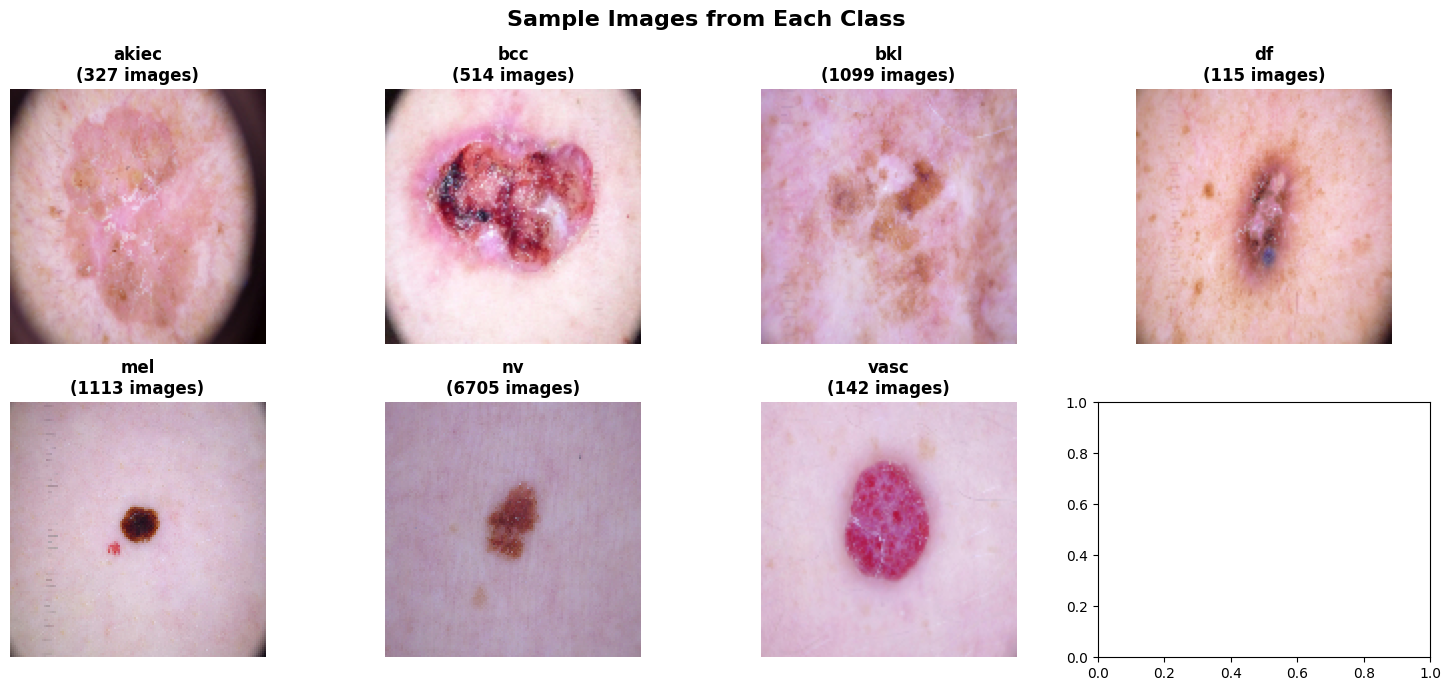

✓ If images look correct above, data loading works!


In [25]:
print("\n" + "="*70)
print("VISUALIZING SAMPLES (Verify images load correctly)")
print("="*70)

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for idx, lesion_type in enumerate(sorted(df['dx'].unique())):
    ax = axes[idx // 4, idx % 4]
    sample = df[df['dx'] == lesion_type].iloc[0]
    img = cv2.imread(sample['path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    ax.imshow(img)
    count = len(df[df['dx'] == lesion_type])
    ax.set_title(f"{lesion_type}\n({count} images)", fontweight='bold')
    ax.axis('off')
plt.suptitle("Sample Images from Each Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ If images look correct above, data loading works!")

In [26]:
print("\n" + "="*70)
print("STEP 2: BALANCE DATASET")
print("="*70)

# Simple strategy: Sample 1000 from each class (with replacement if needed)
balanced_dfs = []
for lesion_type in df['dx'].unique():
    class_df = df[df['dx'] == lesion_type]
    # Take 1000 samples (with replacement if class has < 1000)
    sampled = class_df.sample(n=1000, replace=True, random_state=42)
    balanced_dfs.append(sampled)
    print(f"{lesion_type}: {len(class_df)} → 1000")

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal samples: {len(df_balanced)}")
print("\nBalanced distribution:")
print(df_balanced['dx'].value_counts())


STEP 2: BALANCE DATASET
bkl: 1099 → 1000
nv: 6705 → 1000
df: 115 → 1000
mel: 1113 → 1000
vasc: 142 → 1000
bcc: 514 → 1000
akiec: 327 → 1000

Total samples: 7000

Balanced distribution:
dx
akiec    1000
df       1000
bkl      1000
vasc     1000
mel      1000
bcc      1000
nv       1000
Name: count, dtype: int64


In [27]:
# ============================================================================
print("\n" + "="*70)
print("STEP 3: SPLIT DATA")
print("="*70)

X_train, X_temp, y_train, y_temp = train_test_split(
    df_balanced['path'].values,
    df_balanced['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label'].values
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")



STEP 3: SPLIT DATA

Train: 5600
Val:   700
Test:  700


In [28]:
print("\n" + "="*70)
print("STEP 4: LOAD IMAGES")
print("="*70)
print("Loading images... (this takes 2-3 minutes)")

IMG_SIZE = 128

def load_image(path):
    """Simple image loading with error handling"""
    try:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype('float32') / 255.0  # Normalize to [0, 1]
        return img
    except:
        print(f"Failed to load: {path}")
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype='float32')

# Load all images
X_train_imgs = np.array([load_image(p) for p in tqdm(X_train, desc="Train")])
X_val_imgs = np.array([load_image(p) for p in tqdm(X_val, desc="Val  ")])
X_test_imgs = np.array([load_image(p) for p in tqdm(X_test, desc="Test ")])

print(f"\n✓ Train images: {X_train_imgs.shape}")
print(f"✓ Val images:   {X_val_imgs.shape}")
print(f"✓ Test images:  {X_test_imgs.shape}")

# Verify normalization
print(f"\nPixel value range: [{X_train_imgs.min():.3f}, {X_train_imgs.max():.3f}]")
print(f"Mean pixel value: {X_train_imgs.mean():.3f}")

if X_train_imgs.min() < 0 or X_train_imgs.max() > 1:
    print("⚠ WARNING: Images not properly normalized!")

# Convert labels to one-hot
y_train_cat = keras.utils.to_categorical(y_train, 7)
y_val_cat = keras.utils.to_categorical(y_val, 7)
y_test_cat = keras.utils.to_categorical(y_test, 7)


STEP 4: LOAD IMAGES
Loading images... (this takes 2-3 minutes)


Test : 100%|██████████| 700/700 [00:04<00:00, 153.04it/s]



✓ Train images: (5600, 128, 128, 3)
✓ Val images:   (700, 128, 128, 3)
✓ Test images:  (700, 128, 128, 3)

Pixel value range: [0.000, 1.000]
Mean pixel value: 0.642


In [29]:
print("\n" + "="*70)
print("STEP 5: BUILD SIMPLE MODEL")
print("="*70)

model = keras.Sequential([
    # Input
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.3),

    # Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(7, activation='softmax')
])

model.summary()


STEP 5: BUILD SIMPLE MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,663 (432.28 KB)

 Trainable params: 110,663 (432.28 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
print("\n" + "="*70)
print("STEP 6: COMPILE MODEL")
print("="*70)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model compiled successfully")
print("✓ Using balanced data (no class weights needed)")


STEP 6: COMPILE MODEL
✓ Model compiled successfully
✓ Using balanced data (no class weights needed)


In [31]:
print("\n" + "="*70)
print("STEP 7: TRAIN MODEL")
print("="*70)
print("\nWhat to expect:")
print("  Epoch 1-2:  Accuracy should be > 20% (better than random)")
print("  Epoch 5-10: Accuracy should reach 40-60%")
print("  Epoch 20+:  Accuracy should reach 65-75%")
print("\n⚠ If accuracy stays < 20% after 5 epochs, STOP - something is wrong!")
print("="*70 + "\n")

# Simple callbacks
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

EPOCHS = 50
BATCH_SIZE = 32

history = model.fit(
    X_train_imgs, y_train_cat,
    validation_data=(X_val_imgs, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)



STEP 7: TRAIN MODEL

What to expect:
  Epoch 1-2:  Accuracy should be > 20% (better than random)
  Epoch 5-10: Accuracy should reach 40-60%
  Epoch 20+:  Accuracy should reach 65-75%

⚠ If accuracy stays < 20% after 5 epochs, STOP - something is wrong!

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1588 - loss: 1.9377
Epoch 1: val_accuracy improved from -inf to 0.24286, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.1590 - loss: 1.9375 - val_accuracy: 0.2429 - val_loss: 1.8567
Epoch 2/50
173/175 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2548 - loss: 1.8255
Epoch 2: val_accuracy improved from 0.24286 to 0.33143, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2551 - loss: 1.8248 - val_accuracy: 0.3314 - val_loss: 1.6748
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3536 - loss: 1.6461
Epoch 3: val_accuracy improved from 0.33143 to 0.43714, saving model to 

In [34]:
print("\n" + "="*70)
print("STEP 8: EVALUATE MODEL")
print("="*70)

# Load best model
model = keras.models.load_model('best_model.keras')

# Predictions
y_pred_proba = model.predict(X_test_imgs, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

from sklearn.metrics import accuracy_score
test_acc = accuracy_score(y_test, y_pred)
print(f"\n{'='*70}")
print(f"FINAL TEST ACCURACY: {test_acc*100:.2f}%")
print(f"{'='*70}")

# Detailed report
class_names = sorted(df['dx'].unique())
print("\nPer-class Performance:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))


STEP 8: EVALUATE MODEL

FINAL TEST ACCURACY: 65.43%

Per-class Performance:
              precision    recall  f1-score   support

       akiec      0.646     0.620     0.633       100
         bcc      0.512     0.640     0.569       100
         bkl      0.688     0.440     0.537       100
          df      0.655     0.720     0.686       100
         mel      0.512     0.660     0.576       100
          nv      0.708     0.510     0.593       100
        vasc      0.952     0.990     0.971       100

    accuracy                          0.654       700
   macro avg      0.667     0.654     0.652       700
weighted avg      0.667     0.654     0.652       700




STEP 9: VISUALIZE RESULTS


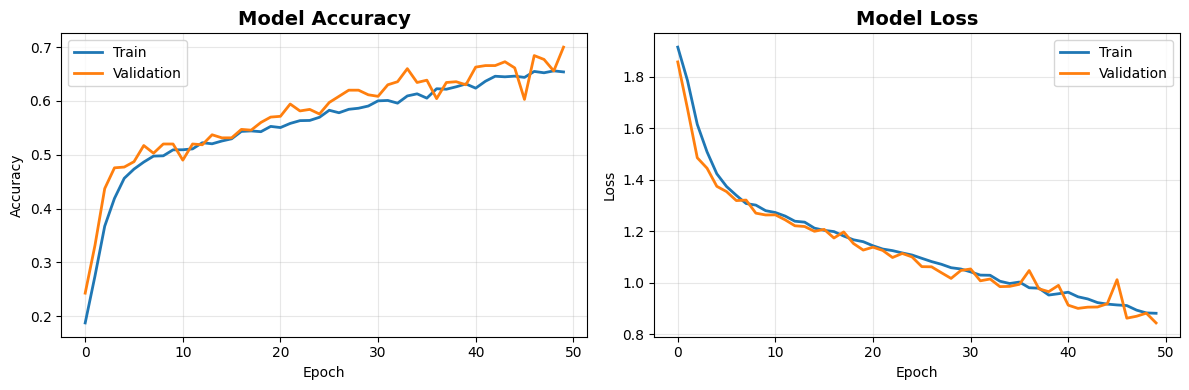

In [35]:
print("\n" + "="*70)
print("STEP 9: VISUALIZE RESULTS")
print("="*70)

# 1. Training History
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

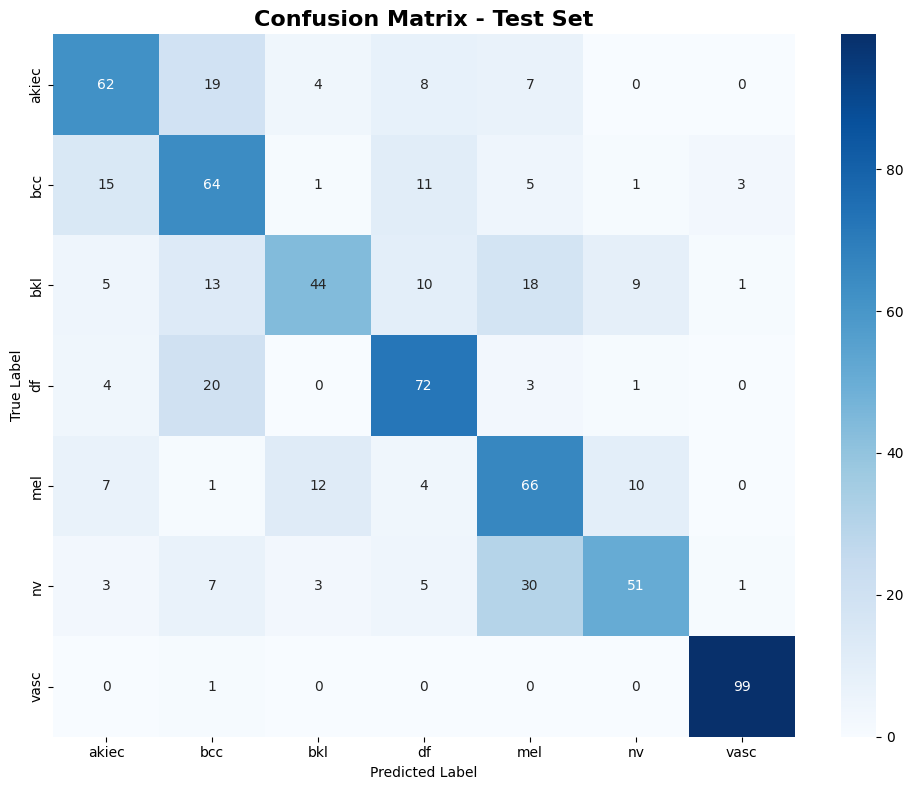

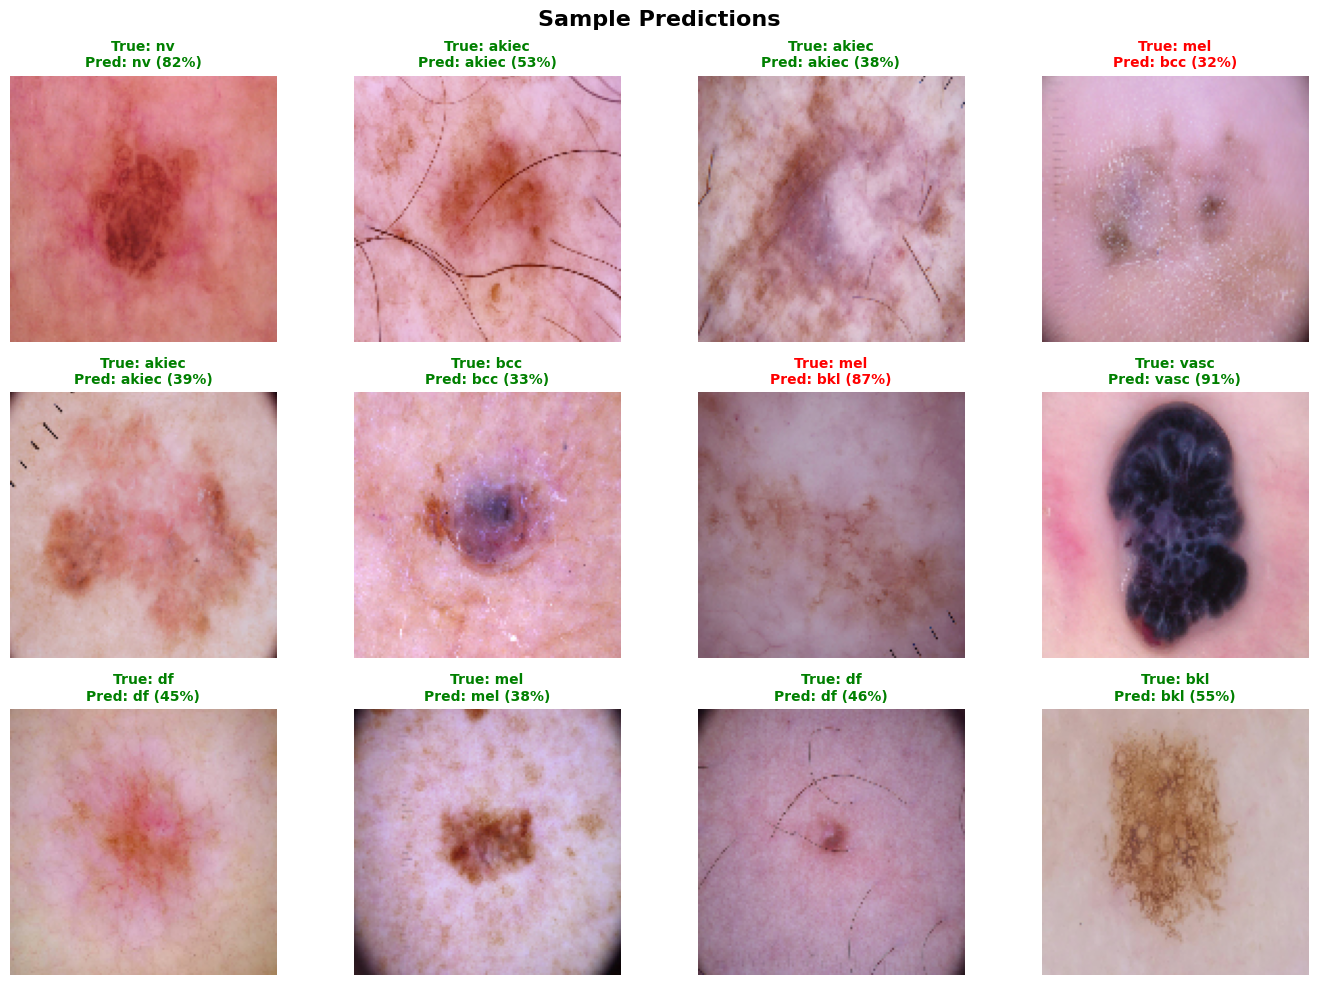

In [36]:
# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 3. Sample Predictions
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
indices = np.random.choice(len(X_test), 12, replace=False)

for idx, i in enumerate(indices):
    ax = axes[idx // 4, idx % 4]
    ax.imshow(X_test_imgs[i])

    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]
    confidence = y_pred_proba[i][y_pred[i]] * 100

    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)',
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
print("\n" + "="*70)
print("BASELINE MODEL COMPLETE!")
print("="*70)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")
print("\nPerformance Assessment:")
if test_acc >= 0.70:
    print("  ✓ EXCELLENT - Model is learning well!")
    print("  → Ready to add improvements")
elif test_acc >= 0.60:
    print("  ✓ GOOD - Model is learning")
    print("  → Can proceed with improvements")
elif test_acc >= 0.40:
    print("  ⚠ MODERATE - Model is learning but struggling")
    print("  → May need data investigation")
else:
    print("  ✗ POOR - Model is not learning properly")
    print("  → Check data loading and preprocessing")




BASELINE MODEL COMPLETE!

Final Test Accuracy: 65.43%

Performance Assessment:
  ✓ GOOD - Model is learning
  → Can proceed with improvements
